# Predicția Distanței de Aterizare — Modele Avansate
## Comparație exhaustivă + selecție automată cel mai bun model


## 1. Import librării

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from math import radians, sin, cos, sqrt, atan2

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               AdaBoostRegressor, GradientBoostingRegressor)
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                      TimeSeriesSplit, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import xgboost as xgb

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

print("Toate librariile incarcate cu succes!")


Toate librariile incarcate cu succes!


## 2. Încărcare și pregătire date

In [2]:
# Incarca datele
df_sh = pd.read_csv(r"D:\User\Documents\GitHub\ML---proiect\Date\sondehub_europe_all.csv")
df_sh['datetime'] = pd.to_datetime(df_sh['datetime'], utc=True, errors='coerce')
df_sh = df_sh[df_sh['datetime'].dt.year >= 2022]
df_sh = df_sh[df_sh['alt'] >= 0]
df_sh = df_sh[df_sh['alt'] < 45000]
df_sh = df_sh.drop_duplicates(subset=['serial', 'datetime'])

print(f"SondeHub: {len(df_sh):,} puncte, {df_sh['serial'].nunique():,} lansari")


SondeHub: 183,298 puncte, 67,818 lansari


In [3]:
# Recalculeaza target
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

rezultate = []
for serial, grup in df_sh.groupby('serial'):
    grup = grup.sort_values('datetime')
    if len(grup) < 3:
        continue
    primul  = grup.iloc[0]
    ultimul = grup.iloc[-1]
    rezultate.append({
        'serial':            serial,
        'lat_lansare':       primul['lat'],
        'lon_lansare':       primul['lon'],
        'alt_max_m':         grup['alt'].max(),
        'dist_aterizare_km': haversine(primul['lat'], primul['lon'],
                                       ultimul['lat'], ultimul['lon']),
        'durata_min':        (grup['datetime'].max() - grup['datetime'].min()).total_seconds() / 60,
        'luna':              primul['datetime'].month,
    })

df_target = pd.DataFrame(rezultate)
print(f"Target calculat: {len(df_target):,} lansari")


Target calculat: 54,641 lansari


In [4]:
# Features agregate per lansare
features_sh = df_sh.groupby('serial').agg(
    vel_h_mean   = ('vel_h',    'mean'),
    vel_h_max    = ('vel_h',    'max'),
    vel_v_mean   = ('vel_v',    'mean'),
    vel_v_max    = ('vel_v',    'max'),
    temp_min     = ('temp',     'min'),
    temp_mean    = ('temp',     'mean'),
    heading_mean = ('heading',  'mean'),
    heading_std  = ('heading',  'std'),
    nr_puncte    = ('alt',      'count'),
).reset_index()

df = df_target.merge(features_sh, on='serial', how='left')

# Feature engineering
df['anotimp'] = df['luna'].map({
    12:0, 1:0, 2:0,
    3:1,  4:1, 5:1,
    6:2,  7:2, 8:2,
    9:3, 10:3, 11:3
})
df['ratio_h_v'] = df['vel_h_mean'] / (df['vel_v_mean'].abs() + 0.1)

import math
def dist_centru(lat, lon, lat_c=47.5, lon_c=19.0):
    R = 6371
    lat1, lon1 = math.radians(lat), math.radians(lon)
    lat2, lon2 = math.radians(lat_c), math.radians(lon_c)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

df['dist_fata_centru'] = df.apply(
    lambda r: dist_centru(r['lat_lansare'], r['lon_lansare']), axis=1
)

print(f"Dataset final: {len(df):,} lansari, {len(df.columns)} coloane")


Dataset final: 54,641 lansari, 19 coloane


In [5]:
# Curatare si filtrare
df = df[df['dist_aterizare_km'] >= 1]
df = df[df['dist_aterizare_km'] <= 600]
df = df[df['alt_max_m'] >= 5000]
df = df[df['alt_max_m'] <= 45000]
df = df[df['vel_h_max'] <= 150]

# Imputa valori lipsa
for col in ['vel_v_mean', 'vel_v_max', 'temp_min', 'temp_mean',
            'heading_std', 'ratio_h_v']:
    df[col] = df[col].fillna(df[col].median())

FEATURES = [
    'lat_lansare', 'lon_lansare',
    'alt_max_m', 'durata_min',
    'vel_h_mean', 'vel_h_max',
    'vel_v_mean', 'vel_v_max',
    'temp_min', 'temp_mean',
    'heading_mean', 'heading_std',
    'nr_puncte', 'ratio_h_v',
    'dist_fata_centru', 'luna', 'anotimp',
]

TARGET = 'dist_aterizare_km'

df_model = df[FEATURES + [TARGET]].dropna()
print(f"Randuri pentru model: {len(df_model):,}")

X = df_model[FEATURES]
y = np.log1p(df_model[TARGET])  # log-transform

print(f"Statistici target (km):")
print(np.expm1(y).describe().round(2))


Randuri pentru model: 54,203
Statistici target (km):
count    54203.00
mean        94.30
std         70.53
min          1.01
25%         42.95
50%         75.97
75%        127.92
max        596.01
Name: dist_aterizare_km, dtype: float64


In [7]:
# Train/Test Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train):,} lansari")
print(f"Test:  {len(X_test):,} lansari")

# Normalizare (StandardScaler)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\nNormalizare aplicata!")


Train: 43,362 lansari
Test:  10,841 lansari

Normalizare aplicata!


## 3. Definire modele și parametri

In [8]:
# Modele de baza
base_models = {
    "Linear Regression":  LinearRegression(),
    "Ridge":              Ridge(),
    "Lasso":              Lasso(),
    "Decision Tree":      DecisionTreeRegressor(random_state=42),
    "Random Forest":      RandomForestRegressor(random_state=42, n_jobs=-1),
    "Extra Trees":        ExtraTreesRegressor(random_state=42, n_jobs=-1),
    "AdaBoost":           AdaBoostRegressor(random_state=42),
    "Gradient Boosting":  GradientBoostingRegressor(random_state=42),
    "XGBoost":            xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
}

# Grile de hiperparametri pentru RandomizedSearchCV
param_grids = {
    "Linear Regression": {},
    "Ridge": {
        "alpha": uniform(0.01, 19.9)
    },
    "Lasso": {
        "alpha": uniform(0.01, 5.0)
    },
    "Decision Tree": {
        'max_depth':         [3, 5, 8, 12, 15, None],
        'min_samples_split': randint(2, 21),
        'min_samples_leaf':  randint(1, 5),
        'criterion':         ['squared_error', 'friedman_mse']
    },
    "Random Forest": {
        'n_estimators':    randint(100, 501),
        'max_depth':       [5, 8, 15, 25, None],
        'min_samples_leaf': randint(1, 5),
        'max_features':    [None, 'sqrt', 'log2'],
        'bootstrap':       [True, False]
    },
    "Extra Trees": {
        'n_estimators':      randint(100, 501),
        'max_depth':         [5, 10, 20, None],
        'min_samples_split': randint(2, 11),
        'bootstrap':         [True, False]
    },
    "AdaBoost": {
        'n_estimators':  randint(50, 301),
        'learning_rate': uniform(0.01, 0.99),
        'loss':          ['linear', 'square', 'exponential']
    },
    "Gradient Boosting": {
        'n_estimators':  randint(100, 501),
        'learning_rate': uniform(0.01, 0.1),
        'max_depth':     randint(3, 7),
        'subsample':     uniform(0.6, 0.4),
    },
    "XGBoost": {
        'n_estimators':    randint(100, 501),
        'learning_rate':   uniform(0.01, 0.09),
        'max_depth':       randint(3, 10),
        'subsample':       uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'gamma':           uniform(0, 0.2)
    }
}

print(f"Modele definite: {list(base_models.keys())}")


Modele definite: ['Linear Regression', 'Ridge', 'Lasso', 'Decision Tree', 'Random Forest', 'Extra Trees', 'AdaBoost', 'Gradient Boosting', 'XGBoost']


## 4. Antrenare cu RandomizedSearchCV

In [9]:
# TimeSeriesSplit pentru cross-validation
tscv = TimeSeriesSplit(n_splits=5)

rezultate_modele = {}

print(f"{'Model':<22} | {'Train R²':>9} | {'Test R²':>9} | {'Variance':>9} | {'Bias':>7} | {'MAE (km)':>9}")
print("-" * 85)

for name, base in base_models.items():
    params = param_grids[name]

    # Folosim date scalate pentru modele liniare, nescalate pentru tree-based
    if name in ["Linear Regression", "Ridge", "Lasso"]:
        Xtr, Xte = X_train_sc, X_test_sc
    else:
        Xtr, Xte = X_train, X_test

    if params:
        search = RandomizedSearchCV(
            base, params,
            n_iter=50,
            cv=tscv,
            scoring='r2',
            n_jobs=-1,
            random_state=42
        )
        search.fit(Xtr, y_train)
        model = search.best_estimator_
    else:
        model = base
        model.fit(Xtr, y_train)

    y_pred_log = model.predict(Xte)

    # Convertim din log
    y_pred_km = np.expm1(y_pred_log)
    y_test_km = np.expm1(y_test)

    train_r2 = model.score(Xtr, y_train)
    test_r2  = r2_score(y_test_km, y_pred_km)
    bias     = 1 - train_r2
    variance = train_r2 - test_r2
    mae      = mean_absolute_error(y_test_km, y_pred_km)
    rmse     = np.sqrt(mean_squared_error(y_test_km, y_pred_km))

    rezultate_modele[name] = {
        'model':    model,
        'train_r2': train_r2,
        'test_r2':  test_r2,
        'bias':     bias,
        'variance': variance,
        'mae':      mae,
        'rmse':     rmse,
        'y_pred':   y_pred_km,
    }

    print(f"{name:<22} | {train_r2:>9.4f} | {test_r2:>9.4f} | {variance:>9.4f} | {bias:>7.4f} | {mae:>9.2f}")

print("-" * 85)
print("Antrenare finalizata!")


Model                  |  Train R² |   Test R² |  Variance |    Bias |  MAE (km)
-------------------------------------------------------------------------------------
Linear Regression      |    0.4100 |    0.3404 |    0.0696 |  0.5900 |     36.87
Ridge                  |    0.4100 |    0.3404 |    0.0696 |  0.5900 |     36.87
Lasso                  |    0.3359 |    0.3389 |   -0.0030 |  0.6641 |     39.07
Decision Tree          |    0.5187 |    0.5637 |   -0.0450 |  0.4813 |     32.66
Random Forest          |    0.9772 |    0.6599 |    0.3173 |  0.0228 |     28.57
Extra Trees            |    0.9983 |    0.6499 |    0.3484 |  0.0017 |     28.91
AdaBoost               |    0.4120 |    0.4146 |   -0.0025 |  0.5880 |     37.03
Gradient Boosting      |    0.6838 |    0.6706 |    0.0132 |  0.3162 |     28.47
XGBoost                |    0.7795 |    0.6793 |    0.1003 |  0.2205 |     28.04
-------------------------------------------------------------------------------------
Antrenare finaliza

## 5. Comparație vizuală modele

In [10]:
df_rez = pd.DataFrame([
    {
        'Model':    name,
        'Train R²': v['train_r2'],
        'Test R²':  v['test_r2'],
        'MAE (km)': v['mae'],
        'RMSE (km)':v['rmse'],
        'Bias':     v['bias'],
        'Variance': v['variance'],
    }
    for name, v in rezultate_modele.items()
]).sort_values('Test R²', ascending=False).reset_index(drop=True)

print("=== CLASAMENT MODELE (dupa Test R²) ===")
print(df_rez.to_string(index=False))


=== CLASAMENT MODELE (dupa Test R²) ===
            Model  Train R²  Test R²  MAE (km)  RMSE (km)     Bias  Variance
          XGBoost  0.779540 0.679258 28.044147  39.732366 0.220460  0.100283
Gradient Boosting  0.683802 0.670631 28.466983  40.263140 0.316198  0.013171
    Random Forest  0.977174 0.659883 28.573442  40.914789 0.022826  0.317291
      Extra Trees  0.998313 0.649881 28.911993  41.512033 0.001687  0.348431
    Decision Tree  0.518689 0.563675 32.655670  46.341627 0.481311 -0.044986
         AdaBoost  0.412046 0.414582 37.028090  53.678382 0.587954 -0.002536
            Ridge  0.409958 0.340399 36.874162  56.977980 0.590042  0.069559
Linear Regression  0.409958 0.340387 36.874205  56.978485 0.590042  0.069571
            Lasso  0.335910 0.338910 39.068173  57.042247 0.664090 -0.003000


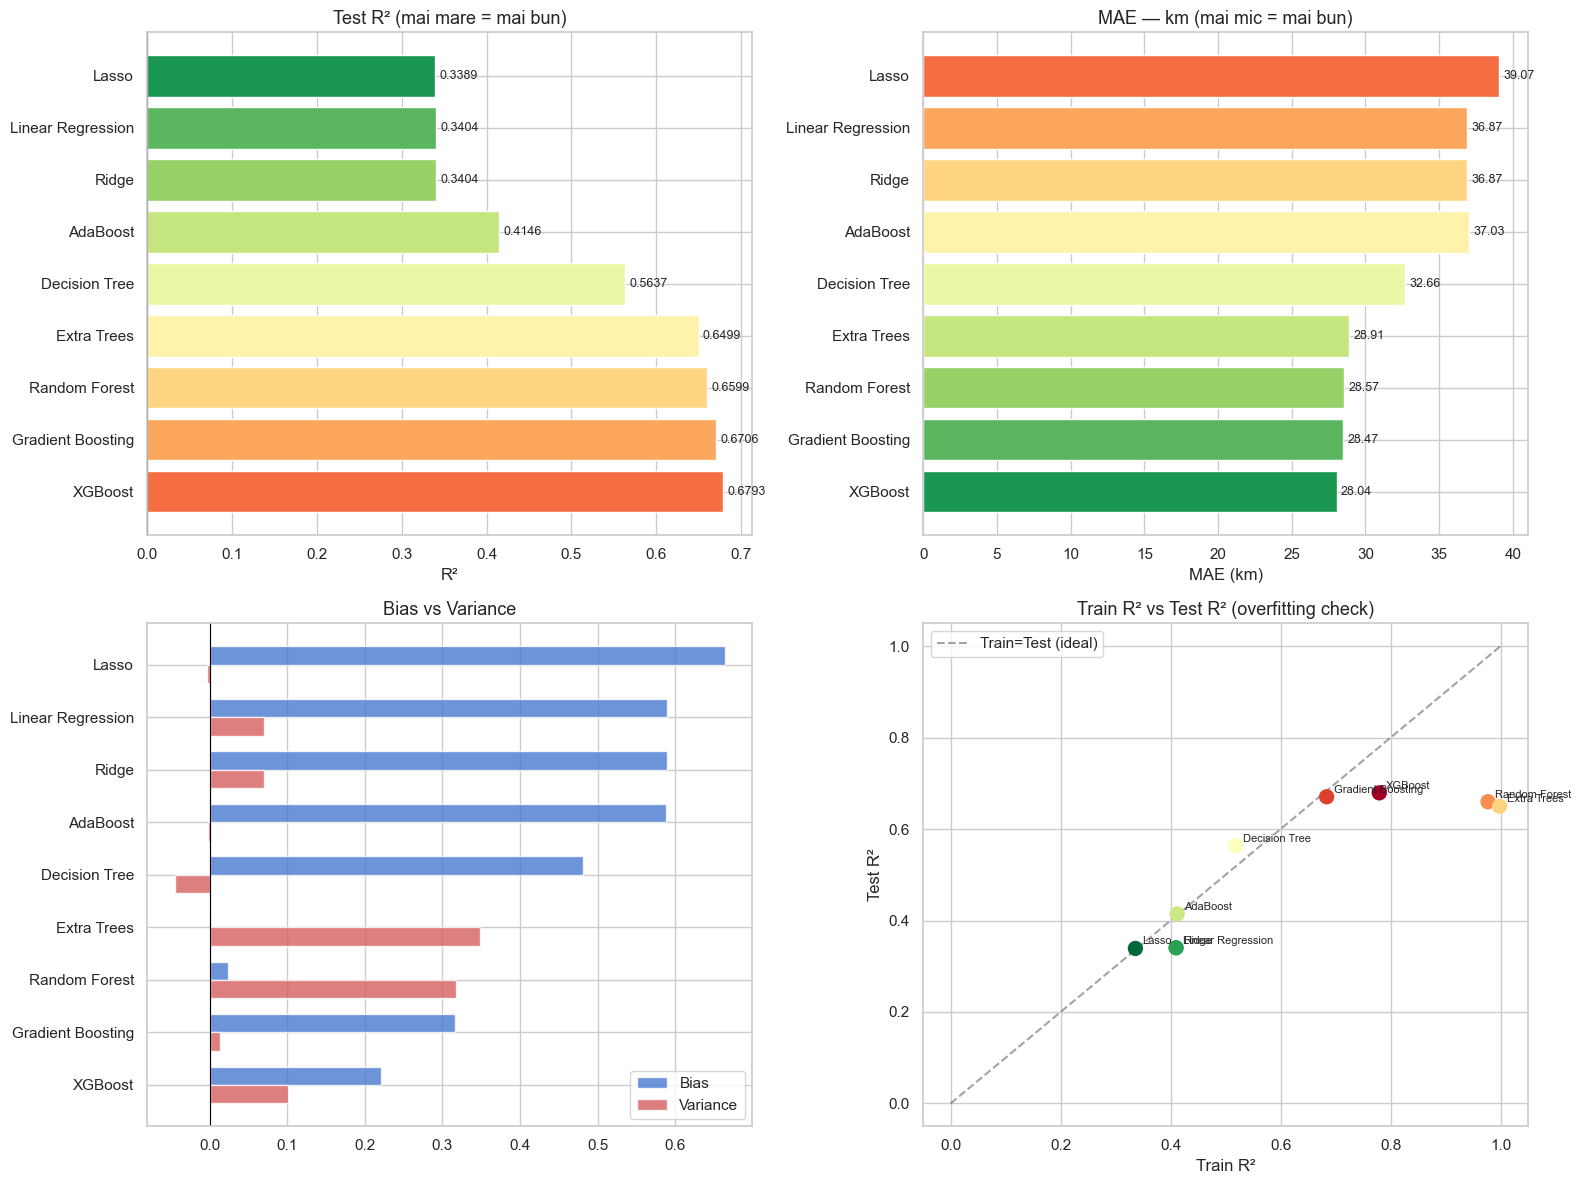

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
modele_names = df_rez['Model'].tolist()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(modele_names)))

# Test R²
axes[0,0].barh(modele_names, df_rez['Test R²'], color=colors)
axes[0,0].set_title('Test R² (mai mare = mai bun)', fontsize=13)
axes[0,0].set_xlabel('R²')
axes[0,0].axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(df_rez['Test R²']):
    axes[0,0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# MAE
axes[0,1].barh(modele_names, df_rez['MAE (km)'], color=colors[::-1])
axes[0,1].set_title('MAE — km (mai mic = mai bun)', fontsize=13)
axes[0,1].set_xlabel('MAE (km)')
for i, v in enumerate(df_rez['MAE (km)']):
    axes[0,1].text(v + 0.3, i, f'{v:.2f}', va='center', fontsize=9)

# Bias vs Variance
x = np.arange(len(modele_names))
w = 0.35
axes[1,0].barh(x + w/2, df_rez['Bias'],     w, label='Bias',     color='#4878CF', alpha=0.8)
axes[1,0].barh(x - w/2, df_rez['Variance'], w, label='Variance', color='#D65F5F', alpha=0.8)
axes[1,0].set_yticks(x)
axes[1,0].set_yticklabels(modele_names)
axes[1,0].set_title('Bias vs Variance', fontsize=13)
axes[1,0].legend()
axes[1,0].axvline(0, color='black', linewidth=0.8)

# Train R² vs Test R²
axes[1,1].scatter(df_rez['Train R²'], df_rez['Test R²'],
                  s=100, c=range(len(df_rez)), cmap='RdYlGn', zorder=3)
for _, row in df_rez.iterrows():
    axes[1,1].annotate(row['Model'],
                       (row['Train R²'], row['Test R²']),
                       textcoords="offset points", xytext=(5, 3), fontsize=8)
axes[1,1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Train=Test (ideal)')
axes[1,1].set_xlabel('Train R²')
axes[1,1].set_ylabel('Test R²')
axes[1,1].set_title('Train R² vs Test R² (overfitting check)', fontsize=13)
axes[1,1].legend()

plt.tight_layout()
plt.savefig('comparatie_avansata.png', dpi=150)
plt.show()


## 6. Predicții vs Real — Top 3 modele

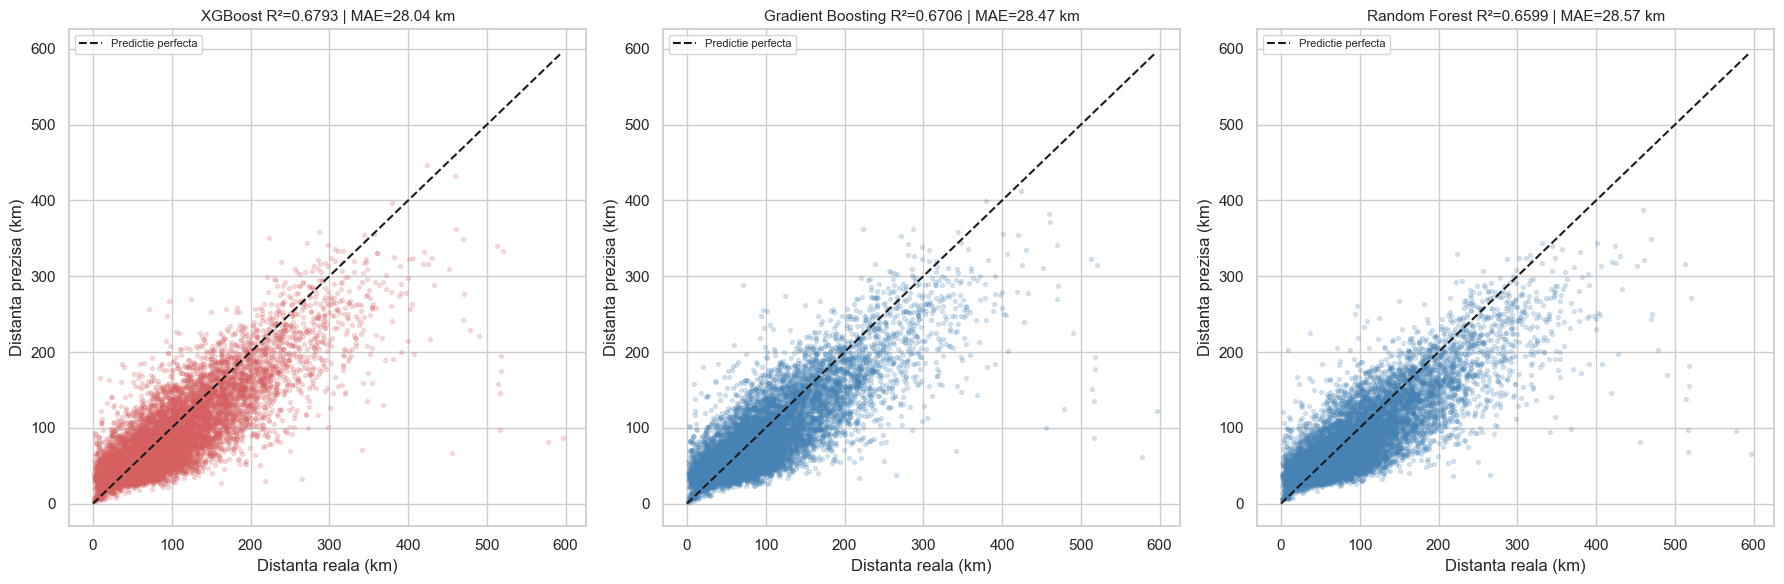

In [13]:
top3 = df_rez.head(3)['Model'].tolist()
y_test_km = np.expm1(y_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, name in zip(axes, top3):
    y_pred = rezultate_modele[name]['y_pred']
    r2     = rezultate_modele[name]['test_r2']
    mae    = rezultate_modele[name]['mae']

    ax.scatter(y_test_km, y_pred, alpha=0.2, s=8,
               color='steelblue' if name != top3[0] else '#D65F5F')
    lim = max(y_test_km.max(), y_pred.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Predictie perfecta')
    ax.set_title(f'{name} R²={r2:.4f} | MAE={mae:.2f} km', fontsize=11)
    ax.set_xlabel('Distanta reala (km)')
    ax.set_ylabel('Distanta prezisa (km)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('top3_predictii.png', dpi=150)
plt.show()


## 7. Feature Importance — Top 3 modele

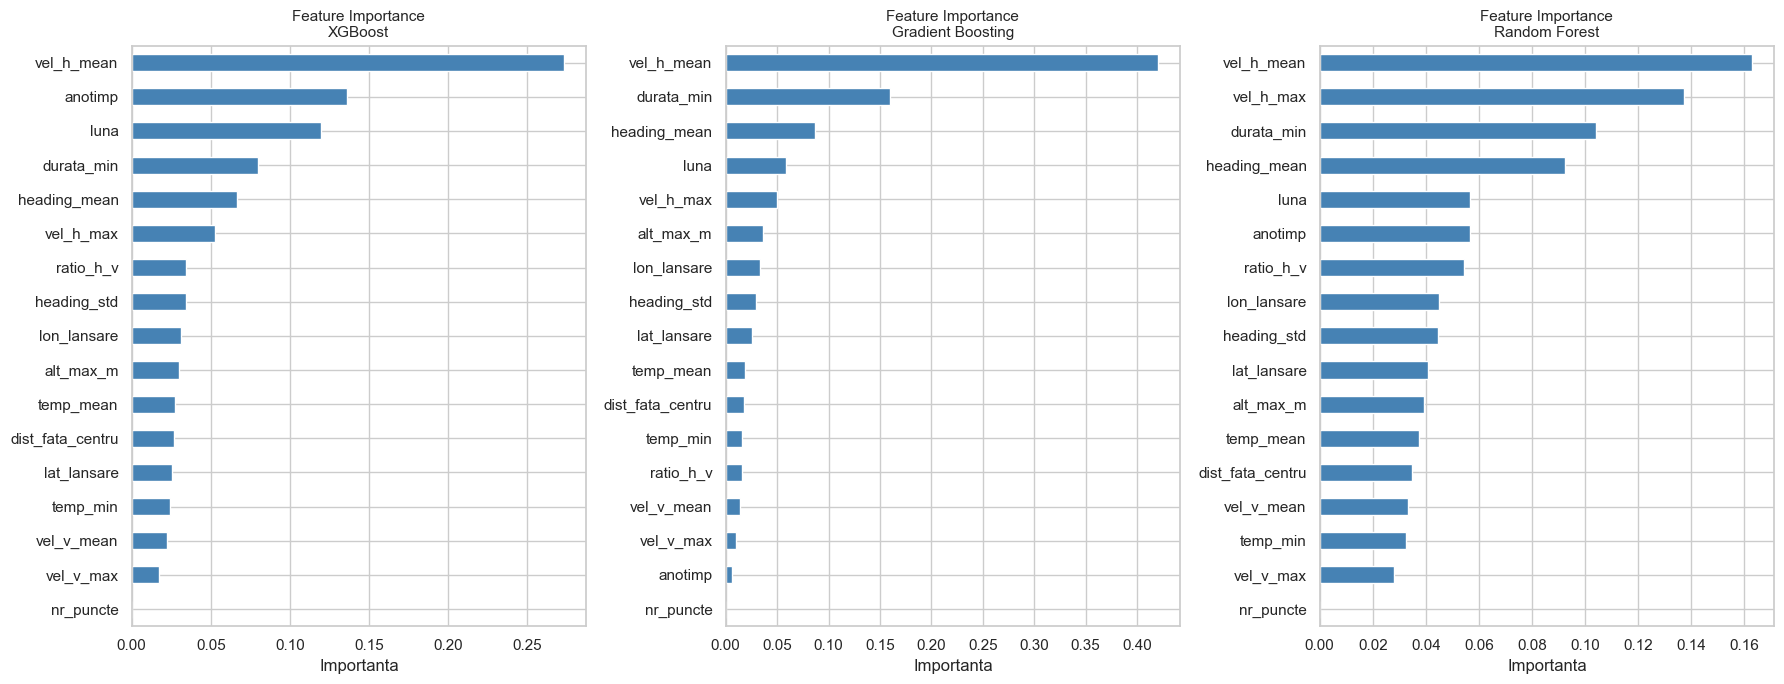

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, name in zip(axes, top3):
    model = rezultate_modele[name]['model']

    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
        imp.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f'Feature Importance\n{name}', fontsize=11)
        ax.set_xlabel('Importanta')
    elif hasattr(model, 'coef_'):
        imp = pd.Series(np.abs(model.coef_), index=FEATURES).sort_values(ascending=True)
        imp.plot(kind='barh', ax=ax, color='darkorange')
        ax.set_title(f'Coeficienti (|val|)\n{name}', fontsize=11)
        ax.set_xlabel('|Coeficient|')

plt.tight_layout()
plt.savefig('feature_importance_top3.png', dpi=150)
plt.show()


## 8. Distribuția erorilor

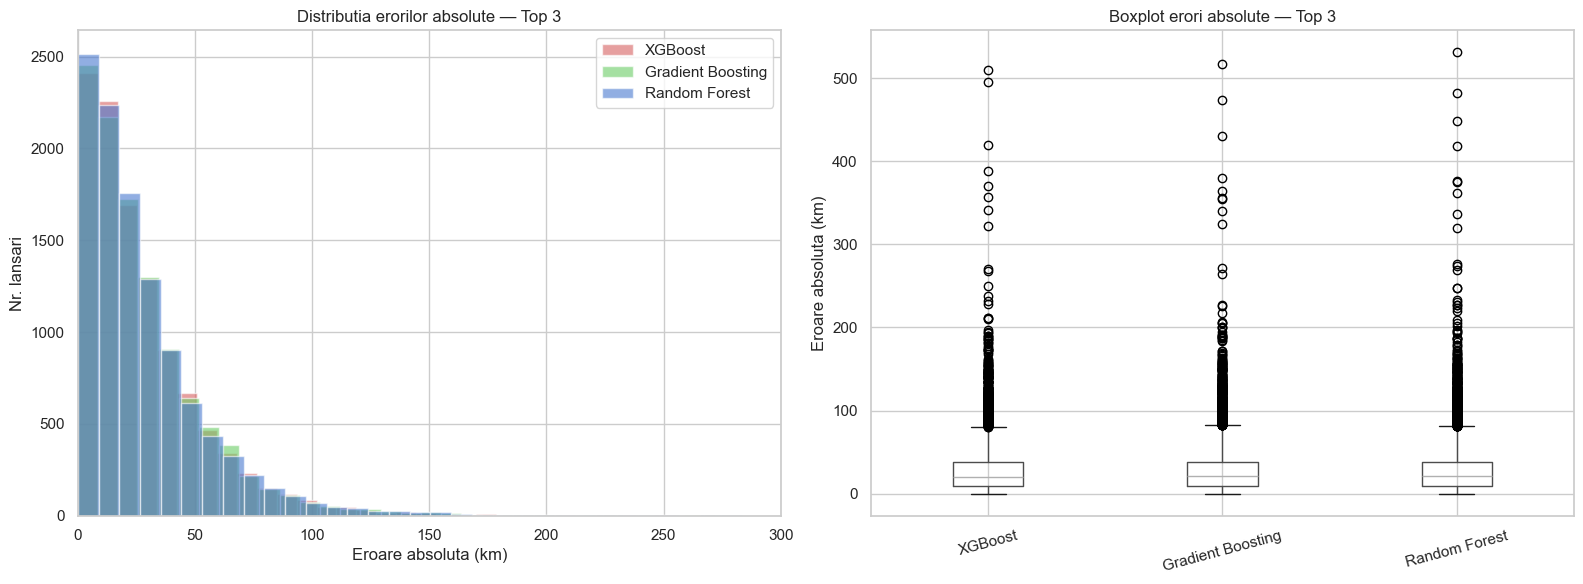

In [15]:
y_test_km = np.expm1(y_test)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_err = ['#D65F5F', '#6ACC65', '#4878CF']
for name, color in zip(top3, colors_err):
    erori = np.abs(y_test_km - rezultate_modele[name]['y_pred'])
    axes[0].hist(erori, bins=60, alpha=0.6, label=name, color=color)

axes[0].set_title('Distributia erorilor absolute — Top 3')
axes[0].set_xlabel('Eroare absoluta (km)')
axes[0].set_ylabel('Nr. lansari')
axes[0].legend()
axes[0].set_xlim(0, 300)

# Boxplot
df_erori = pd.DataFrame({
    name: np.abs(y_test_km - rezultate_modele[name]['y_pred'])
    for name in top3
})
df_erori.boxplot(ax=axes[1])
axes[1].set_title('Boxplot erori absolute — Top 3')
axes[1].set_ylabel('Eroare absoluta (km)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('erori_top3.png', dpi=150)
plt.show()


## 9. Sistem automat de selecție a celui mai bun model

In [16]:
def selecteaza_cel_mai_bun_model(rezultate_modele, w_r2=0.4, w_mae=0.3, w_overfit=0.3):
    """
    Scor compus pentru selectia celui mai bun model:
    - w_r2:      importanta Test R² (mai mare = mai bun)
    - w_mae:     importanta MAE (mai mic = mai bun)
    - w_overfit: penalizare pentru overfitting (Train R² - Test R² mare = rau)
    """
    scoruri = {}

    # Normalizeaza metricile intre 0 si 1
    r2_vals   = np.array([v['test_r2'] for v in rezultate_modele.values()])
    mae_vals  = np.array([v['mae']     for v in rezultate_modele.values()])
    var_vals  = np.array([max(0, v['variance']) for v in rezultate_modele.values()])

    r2_norm  = (r2_vals  - r2_vals.min())  / (r2_vals.max()  - r2_vals.min()  + 1e-9)
    mae_norm = (mae_vals - mae_vals.min()) / (mae_vals.max() - mae_vals.min() + 1e-9)
    var_norm = (var_vals - var_vals.min()) / (var_vals.max() - var_vals.min() + 1e-9)

    for i, name in enumerate(rezultate_modele.keys()):
        scor = (
            w_r2      * r2_norm[i]         # mai mare = mai bun
          + w_mae      * (1 - mae_norm[i]) # mai mic mae = mai bun
          + w_overfit  * (1 - var_norm[i]) # mai mic overfit = mai bun
        )
        scoruri[name] = round(scor, 4)

    # Sorteaza descrescator
    scoruri_sorted = dict(sorted(scoruri.items(), key=lambda x: x[1], reverse=True))

    print("=" * 55)
    print("SISTEM DE SELECTIE — SCOR COMPUS")
    print(f"Ponderi: R²={w_r2} | MAE={w_mae} | Anti-overfit={w_overfit}")
    print("=" * 55)
    for rank, (name, scor) in enumerate(scoruri_sorted.items(), 1):
        v = rezultate_modele[name]
        marker = " ← CEL MAI BUN" if rank == 1 else ""
        print(f"{rank}. {name:<22} Scor={scor:.4f} | R²={v['test_r2']:.4f} | MAE={v['mae']:.2f}km | Overfit={max(0,v['variance']):.4f}{marker}")

    cel_mai_bun_nume  = list(scoruri_sorted.keys())[0]
    cel_mai_bun_model = rezultate_modele[cel_mai_bun_nume]['model']

    print("=" * 55)
    print(f"\nMODELUL SELECTAT: {cel_mai_bun_nume}")
    print(f"  Test R²:  {rezultate_modele[cel_mai_bun_nume]['test_r2']:.4f}")
    print(f"  MAE:      {rezultate_modele[cel_mai_bun_nume]['mae']:.2f} km")
    print(f"  RMSE:     {rezultate_modele[cel_mai_bun_nume]['rmse']:.2f} km")
    print(f"  Overfit:  {max(0, rezultate_modele[cel_mai_bun_nume]['variance']):.4f}")

    return cel_mai_bun_nume, cel_mai_bun_model, scoruri_sorted

best_name, best_model, scoruri = selecteaza_cel_mai_bun_model(rezultate_modele)


SISTEM DE SELECTIE — SCOR COMPUS
Ponderi: R²=0.4 | MAE=0.3 | Anti-overfit=0.3
1. Gradient Boosting      Scor=0.9670 | R²=0.6706 | MAE=28.47km | Overfit=0.0132 ← CEL MAI BUN
2. XGBoost                Scor=0.9137 | R²=0.6793 | MAE=28.04km | Overfit=0.1003
3. Decision Tree          Scor=0.7387 | R²=0.5637 | MAE=32.66km | Overfit=0.0000
4. Random Forest          Scor=0.6896 | R²=0.6599 | MAE=28.57km | Overfit=0.3173
5. Extra Trees            Scor=0.6419 | R²=0.6499 | MAE=28.91km | Overfit=0.3484
6. AdaBoost               Scor=0.4445 | R²=0.4146 | MAE=37.03km | Overfit=0.0000
7. Ridge                  Scor=0.3016 | R²=0.3404 | MAE=36.87km | Overfit=0.0696
8. Linear Regression      Scor=0.3015 | R²=0.3404 | MAE=36.87km | Overfit=0.0696
9. Lasso                  Scor=0.3000 | R²=0.3389 | MAE=39.07km | Overfit=0.0000

MODELUL SELECTAT: Gradient Boosting
  Test R²:  0.6706
  MAE:      28.47 km
  RMSE:     40.26 km
  Overfit:  0.0132


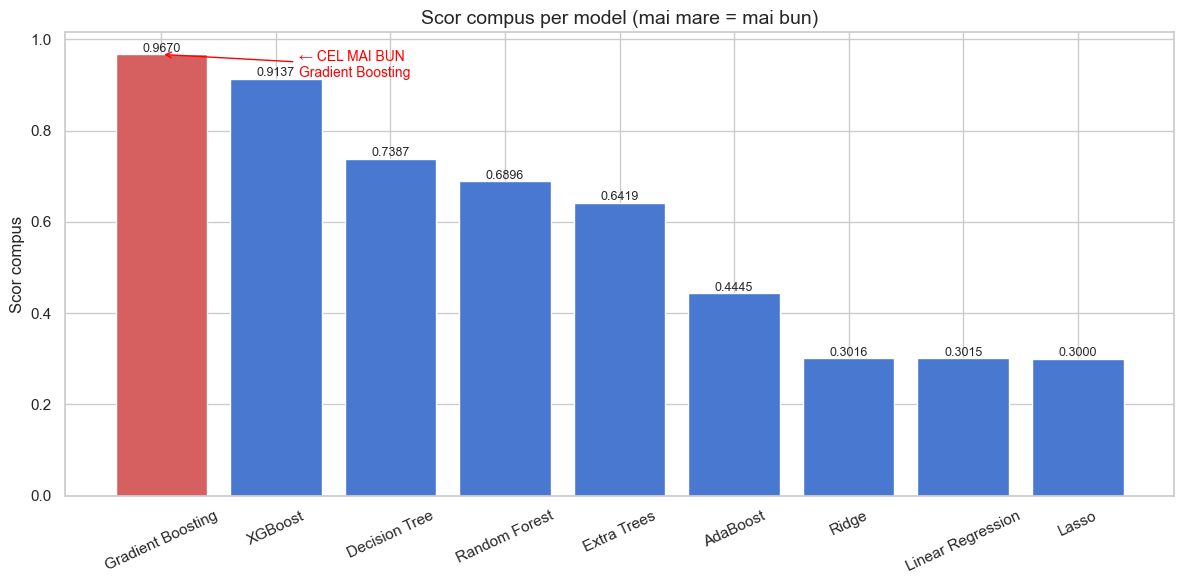

In [17]:
# Vizualizare scoruri compuse
fig, ax = plt.subplots(figsize=(12, 6))
names  = list(scoruri.keys())
values = list(scoruri.values())
colors = ['#D65F5F' if n == best_name else '#4878CF' for n in names]

bars = ax.bar(names, values, color=colors, edgecolor='white')
ax.set_title('Scor compus per model (mai mare = mai bun)', fontsize=14)
ax.set_ylabel('Scor compus')
ax.tick_params(axis='x', rotation=25)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=9)

ax.annotate(f'← CEL MAI BUN\n{best_name}',
            xy=(names.index(best_name), scoruri[best_name]),
            xytext=(names.index(best_name) + 1.2, scoruri[best_name] - 0.05),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

plt.tight_layout()
plt.savefig('scor_compus_modele.png', dpi=150)
plt.show()


## 10. Cel mai bun model — Analiză finală

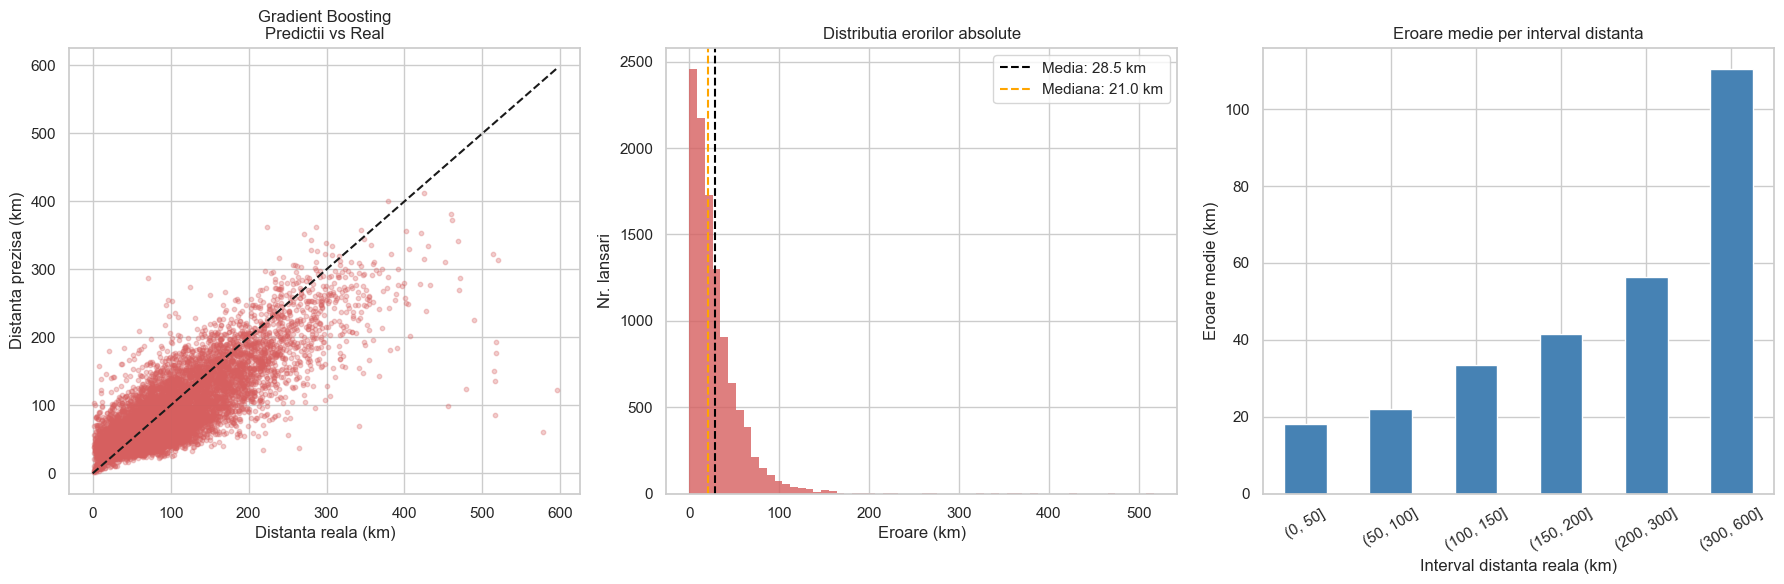


=== ANALIZA FINALA: Gradient Boosting ===
Eroare medie:   28.47 km
Eroare mediana: 20.97 km
50% predictii au eroare sub: 20.97 km
90% predictii au eroare sub: 61.85 km


In [18]:
y_test_km  = np.expm1(y_test)
y_pred_best = rezultate_modele[best_name]['y_pred']
erori_best  = np.abs(y_test_km - y_pred_best)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Predictii vs real
axes[0].scatter(y_test_km, y_pred_best, alpha=0.3, s=10, color='#D65F5F')
lim = max(y_test_km.max(), y_pred_best.max())
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1.5)
axes[0].set_title(f'{best_name}\nPredictii vs Real')
axes[0].set_xlabel('Distanta reala (km)')
axes[0].set_ylabel('Distanta prezisa (km)')

# Distributia erorilor
axes[1].hist(erori_best, bins=60, color='#D65F5F', edgecolor='none', alpha=0.8)
axes[1].axvline(erori_best.mean(),   color='black',  linestyle='--',
                label=f'Media: {erori_best.mean():.1f} km')
axes[1].axvline(erori_best.median(), color='orange', linestyle='--',
                label=f'Mediana: {erori_best.median():.1f} km')
axes[1].set_title('Distributia erorilor absolute')
axes[1].set_xlabel('Eroare (km)')
axes[1].set_ylabel('Nr. lansari')
axes[1].legend()

# Erori per interval de distanta
bins_dist  = pd.cut(y_test_km, bins=[0,50,100,150,200,300,600])
erori_bins = pd.DataFrame({'eroare': erori_best.values, 'interval': bins_dist.values})
erori_bins.groupby('interval')['eroare'].mean().plot(kind='bar', ax=axes[2],
                                                      color='steelblue', edgecolor='white')
axes[2].set_title('Eroare medie per interval distanta')
axes[2].set_xlabel('Interval distanta reala (km)')
axes[2].set_ylabel('Eroare medie (km)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('analiza_finala_best_model.png', dpi=150)
plt.show()

print(f"\n=== ANALIZA FINALA: {best_name} ===")
print(f"Eroare medie:   {erori_best.mean():.2f} km")
print(f"Eroare mediana: {erori_best.median():.2f} km")
print(f"50% predictii au eroare sub: {np.percentile(erori_best, 50):.2f} km")
print(f"90% predictii au eroare sub: {np.percentile(erori_best, 90):.2f} km")
